Analyzing MCMC samples to characterize the system under test through multiple analyses

1) Mean variance plot over all the samples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
file_path = "500000iteration_episode6_mcmc.npz"
data = np.load(file_path)

In [9]:
# NPZ file is a zipped file of multiple numpy arrays. Each array stores a different variable (winds applied, episode length, etc)
for key in data.files:
    print(key, data[key].shape, data[key].dtype) # Print the shape of each array

winds (100001, 350) float32
episode_lengths (100001,) int32
victim_failed (100001,) bool
failure_steps (100001,) int32
max_wind () float32
wind_sigma () float32
horizon () int32
chain (100001, 350) float32
log_scores (100001,) float64
accepted (100000,) bool
proposal_failed (100000,) bool
proposal_failure_steps (100000,) int32
proposal_out_of_bounds (100000,) bool
proposal_log_scores (100000,) float64
acceptance_probabilities (100000,) float64
initial_trace (350,) float32
source_episode_index () int32
source_episode_length () int32
source_failure_step () int32
source_horizon () int32
source_wind_sigma () float32
natural_wind_sigma () float64
env_seed () int64
proposal_sigma () float64
proposal_mode () <U3
block_size () int32
mcmc_seed () int64
iterations () int32


In [16]:
chain = data['chain']
failure_steps = data['failure_steps']

num_timesteps = np.arange(chain.shape[1]) # 350 timesteps in each failure trace

mean_wind = np.empty(len(num_timesteps))
variance = np.empty(len(num_timesteps))
std_wind = np.empty(len(num_timesteps))
for i in range(len(num_timesteps)):
    mean_wind[i] = np.mean(chain[:, i])
    variance[i] = np.var(chain[:, i])
    std_wind[i] = np.std(chain[:, i])

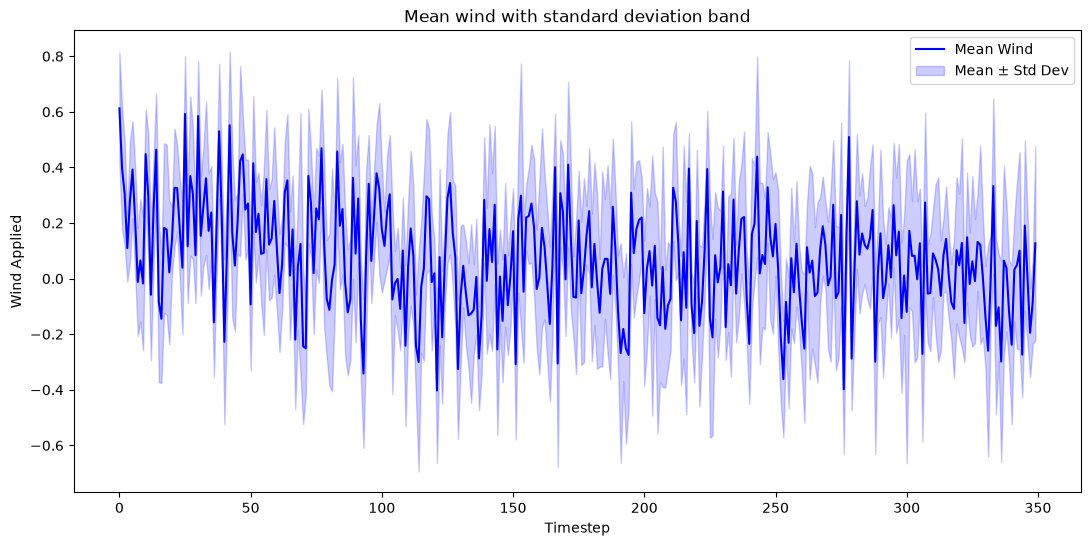

In [ ]:
# MEAN WIND WITH STANDARD DEVIATION BAND PLOT

# Creates empty canvas of X inches wide and Y inches tall
plt.figure(figsize=(13, 6)) 

# Plots
plt.plot(num_timesteps, mean_wind, label="Mean Wind", color="blue")
plt.fill_between(num_timesteps, mean_wind - std_wind, mean_wind + std_wind, color="blue", alpha=0.2, label="Mean ± Std Dev") # Shade in uncertainty region (mean +- std)

# Graphing conventions
plt.xlabel("Timestep")
plt.ylabel("Wind Applied")
plt.title("Mean wind with standard deviation band")
plt.legend()
plt.show()

The mean wind starts positive (right direction), then drops more towards negative and starts to keep changing direction later in the episode, so it shows that both wind directions can cause failure. 

The std band is wide everywhere, suggesting that many different wind values can produce failure. 

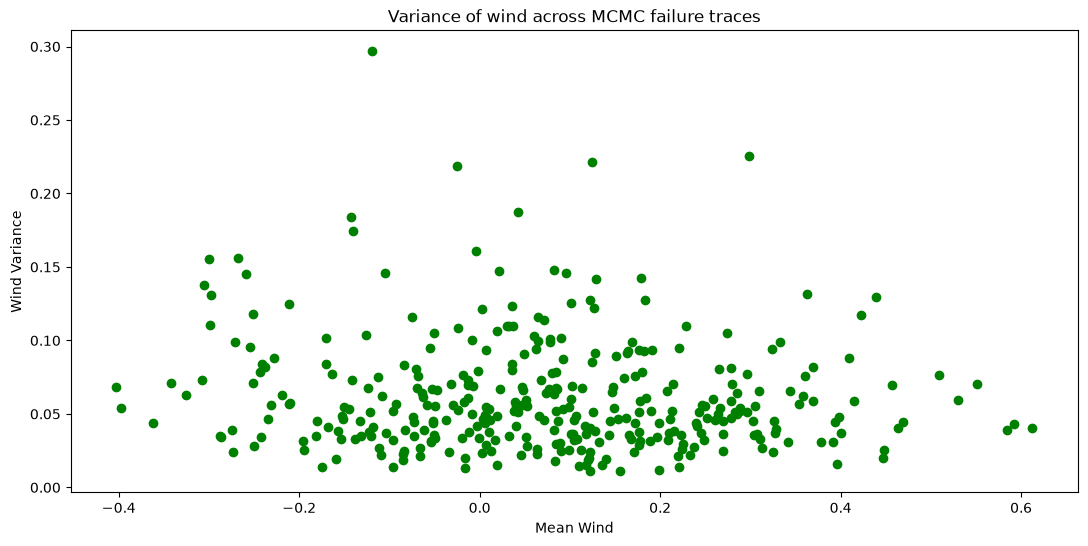

In [24]:
# MEAN-VARIANCE SCATTER PLOT

plt.figure(figsize=(13, 6))

plt.scatter(mean_wind, variance, label="Mean vs Variance", color="green")
plt.xlabel("Mean Wind")
plt.ylabel("Wind Variance")
plt.title("Variance of wind across MCMC failure traces")
plt.show()

First, most timesteps have positive wind, so wind in the right direction seems more useful for failures. 
There isn't any trend really between larger winds and larger variance. 

In [ ]:
# STD vs Timestep Plot